# ROI Crop Investigation

## Objective

This notebook investigates the actual ROI extraction step used by the PANORAMA preprocessing pipeline.

The investigation has three goals:

1. Verify exactly how the pancreas-centered ROI is generated.
2. Verify that the PDAC lesion annotation is not used to determine the crop location.
3. Evaluate whether the generated ROI contains the pancreas and PDAC lesion while retaining surrounding anatomical context.

## Important methodological point

The analysis must be performed on data **before the production crop is applied**.

The processed `.npy` files already have the final size of:

128 × 160 × 192

Therefore, using those files to reconstruct the ROI would only analyze the already-cropped volume and could not determine whether the original crop excluded anatomy.

For this reason, this notebook loads the remaining raw CT volumes and their original segmentation masks, reproduces the preprocessing steps up to the crop, and then evaluates the crop boundaries.

## Research Question

Does the current pancreas-centered ROI extraction procedure generate a suitable fixed-size input region for 3D PDAC classification without using the ground-truth PDAC lesion annotation to determine the crop?

### Labels used in this investigation

- **Label 4:** pancreas. This is used by the production preprocessing pipeline to determine the ROI center.
- **Label 1:** PDAC lesion. This is used only for evaluating whether the already-generated ROI contains the lesion.

The PDAC lesion label must never be used to determine the crop center.

In [1]:
# ============================================================
# Imports and project setup
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RAW_CT_DIR,
    PROCESSED_IMAGES_DIR,
    PROCESSED_MASKS_DIR,
    PROCESSED_METADATA_FILE,
)

from src.io import load_case

from src.preprocessing import (
    DEFAULT_ROI_SIZE,
    DEFAULT_TARGET_SPACING,
    DEFAULT_HU_WINDOW,
    resample_case,
    clip_hu,
    normalize_minmax,
    get_structure_bbox,
    bbox_size,
    bbox_center,
    crop_volume,
)

print("Project root:", PROJECT_ROOT)
print("Raw CT directory:", RAW_CT_DIR)
print("Processed images:", PROCESSED_IMAGES_DIR)

print("\nTarget spacing:", DEFAULT_TARGET_SPACING)
print("ROI size:", DEFAULT_ROI_SIZE)
print("HU window:", DEFAULT_HU_WINDOW)

Project root: D:\Pancreatic_Cancer_Thesis
Raw CT directory: D:\Pancreatic_Cancer_Thesis\data\raw_ct
Processed images: D:\Pancreatic_Cancer_Thesis\data\processed\images

Target spacing: (1.0, 1.0, 3.0)
ROI size: (128, 160, 192)
HU window: (-150, 250)


## Available Raw Cases

The final processed dataset contains 2,238 cases, but the raw CT directory currently contains only the cases that have been retained locally.

These remaining raw cases are sufficient for investigating the actual crop mechanism, but they are not a replacement for the full processed dataset used later for model training.

In [2]:
# ============================================================
# Identify currently available raw cases
# ============================================================

raw_ct_files = sorted(
    RAW_CT_DIR.glob("*_0000.nii.gz")
)

raw_study_ids = [
    p.name.replace("_0000.nii.gz", "")
    for p in raw_ct_files
]

print("Raw CT cases currently available:", len(raw_study_ids))

print("\nFirst 10:")
for study_id in raw_study_ids[:10]:
    print(" ", study_id)

print("\nLast 10:")
for study_id in raw_study_ids[-10:]:
    print(" ", study_id)

Raw CT cases currently available: 536

First 10:
  100936_00001
  101691_00001
  101692_00001
  101693_00001
  101694_00001
  101695_00001
  101696_00001
  101697_00001
  101698_00001
  101699_00001

Last 10:
  102214_00001
  102215_00001
  102216_00001
  102217_00001
  102218_00001
  102219_00001
  102220_00001
  102221_00001
  102222_00001
  102223_00001


In [3]:
# ============================================================
# Match remaining raw cases to final metadata
# ============================================================

metadata = pd.read_csv(PROCESSED_METADATA_FILE)

raw_set = set(raw_study_ids)

raw_metadata = metadata[
    metadata["study_id"].astype(str).isin(raw_set)
].copy()

print("Raw cases matched to metadata:", len(raw_metadata))

print("\nDiagnosis distribution:")
print(raw_metadata["diagnosis"].value_counts())

display(
    raw_metadata[
        ["study_id", "patient_id", "diagnosis"]
    ].head()
)

Raw cases matched to metadata: 536

Diagnosis distribution:
diagnosis
non-PDAC    364
PDAC        172
Name: count, dtype: int64


,study_id,patient_id,diagnosis
946,100936_00001,100936,PDAC
1703,101691_00001,101691,non-PDAC
1704,101692_00001,101692,PDAC
1705,101693_00001,101693,non-PDAC
1706,101694_00001,101694,PDAC


## Representative Raw Cases

We will inspect a small, reproducible sample from the raw cases.

The sample contains both PDAC and non-PDAC cases.

The sample size is deliberately small because this notebook is validating the crop mechanism and visual geometry, not performing the final statistical analysis of the dataset.

In [4]:
# ============================================================
# Select representative cases
# ============================================================

RANDOM_SEED = 42

pdac_raw = raw_metadata[
    raw_metadata["diagnosis"] == "PDAC"
]

non_pdac_raw = raw_metadata[
    raw_metadata["diagnosis"] == "non-PDAC"
]

sample_pdac = pdac_raw.sample(
    n=min(5, len(pdac_raw)),
    random_state=RANDOM_SEED,
)

sample_non_pdac = non_pdac_raw.sample(
    n=min(5, len(non_pdac_raw)),
    random_state=RANDOM_SEED,
)

sample_cases = pd.concat(
    [sample_pdac, sample_non_pdac],
    ignore_index=True,
)

display(
    sample_cases[
        ["study_id", "patient_id", "diagnosis"]
    ]
)

,study_id,patient_id,diagnosis
0,101965_00001,101965,PDAC
1,102115_00001,102115,PDAC
2,102156_00001,102156,PDAC
3,101900_00001,101900,PDAC
4,102166_00001,102166,PDAC
5,101957_00001,101957,non-PDAC
6,101737_00001,101737,non-PDAC
7,101712_00001,101712,non-PDAC
8,102200_00001,102200,non-PDAC
9,101769_00001,101769,non-PDAC


## Production Crop Logic

Before performing measurements, the production implementation is displayed directly from the source code.

The critical operation is:

1. Find the bounding box of label 4.
2. Calculate its center.
3. Use that center to crop the CT volume.

The tumor label is not involved in this calculation.

In [5]:
# ============================================================
# Show the exact production crop function
# ============================================================

import inspect
from src.preprocessing import crop_case

print(inspect.getsource(crop_case))

def crop_case(
    case,
    crop_size=DEFAULT_ROI_SIZE,
    label=4,
):
    """
    Extract a fixed-size ROI centered on the pancreas.

    Parameters
    ----------
    case : dict
        Case dictionary containing CT and mask arrays.

    crop_size : tuple, optional
        Desired output size (depth, height, width).

    label : int, optional
        Label value corresponding to the pancreas.
        Default is 4 for the PANORAMA dataset.

    Returns
    -------
    dict
        Cropped case dictionary.
    """

    new_case = case.copy()

    # ---------------------------------------------------------
    # Compute pancreas bounding box
    # ---------------------------------------------------------

    bbox = get_structure_bbox(
        case["mask_array"],
        label,
    )

    if bbox is None:
        raise ValueError(
            "Pancreas label not found in mask."
        )

    center = bbox_center(bbox)

    # ---------------------------------------------------------


## Reproduce Preprocessing Up to the Crop

For each raw case we will reproduce the production pipeline only up to the point immediately before `crop_case()`:

1. load the raw CT and mask,
2. resample both,
3. clip CT intensities,
4. normalize CT intensities.

At that point we have the same data representation that `crop_case()` receives.

We then calculate the pancreas-centered ROI ourselves for analysis.

The tumor mask is not involved in generating the ROI.

In [6]:
# ============================================================
# Load and prepare one raw case
# ============================================================

study_id = sample_cases.iloc[0]["study_id"]
diagnosis = sample_cases.iloc[0]["diagnosis"]

case = load_case(study_id)

print("Study ID :", study_id)
print("Diagnosis:", diagnosis)

print("\nRaw CT shape :", case["ct_array"].shape)
print("Raw mask shape:", case["mask_array"].shape)

print("\nMask type:", case["mask_type"])
print("CT spacing:", case["ct_image"].GetSpacing())
print("Mask spacing:", case["mask_image"].GetSpacing())

Study ID : 101965_00001
Diagnosis: PDAC

Raw CT shape : (594, 512, 512)
Raw mask shape: (594, 512, 512)

Mask type: Manual
CT spacing: (0.68359375, 0.68359375, 1.0)
Mask spacing: (0.68359375, 0.68359375, 1.0)


In [7]:
# ============================================================
# Reproduce preprocessing before crop
# ============================================================

case_pre_crop = resample_case(
    case,
    target_spacing=DEFAULT_TARGET_SPACING,
)

case_pre_crop["ct_array"] = clip_hu(
    case_pre_crop["ct_array"],
    lower=DEFAULT_HU_WINDOW[0],
    upper=DEFAULT_HU_WINDOW[1],
)

case_pre_crop["ct_array"] = normalize_minmax(
    case_pre_crop["ct_array"]
)

ct_pre_crop = case_pre_crop["ct_array"]
mask_pre_crop = case_pre_crop["mask_array"]

print("Pre-crop CT shape  :", ct_pre_crop.shape)
print("Pre-crop mask shape:", mask_pre_crop.shape)
print("CT range:", ct_pre_crop.min(), ct_pre_crop.max())
print("Mask labels:", np.unique(mask_pre_crop))

Pre-crop CT shape  : (198, 350, 350)
Pre-crop mask shape: (198, 350, 350)
CT range: 0.0 1.0
Mask labels: [0 1 2 3 4 5 6]


In [8]:
# ============================================================
# Calculate pancreas and tumor bounding boxes
# ============================================================

PANCREAS_LABEL = 4
TUMOR_LABEL = 1

pancreas_bbox = get_structure_bbox(
    mask_pre_crop,
    PANCREAS_LABEL,
)

tumor_bbox = get_structure_bbox(
    mask_pre_crop,
    TUMOR_LABEL,
)

print("Pancreas bbox:")
print(pancreas_bbox)

print("\nPancreas size:")
print(bbox_size(pancreas_bbox))

print("\nPancreas center:")
print(bbox_center(pancreas_bbox))

print("\nTumor bbox:")
print(tumor_bbox)

if tumor_bbox is not None:
    print("\nTumor size:")
    print(bbox_size(tumor_bbox))

Pancreas bbox:
(np.int64(83), np.int64(106), np.int64(157), np.int64(213), np.int64(177), np.int64(257))

Pancreas size:
(np.int64(24), np.int64(57), np.int64(81))

Pancreas center:
(np.int64(94), np.int64(185), np.int64(217))

Tumor bbox:
(np.int64(87), np.int64(92), np.int64(157), np.int64(174), np.int64(183), np.int64(205))

Tumor size:
(np.int64(6), np.int64(18), np.int64(23))


## What the Bounding Boxes Mean

A bounding box is simply the smallest rectangular box containing all voxels belonging to a structure.

For example:

- the pancreas bounding box tells us where the pancreas occupies the resampled volume,
- the tumor bounding box tells us where the annotated PDAC lesion occupies the volume.

The tumor bounding box is used here only as an evaluation reference.

The production crop is centered using the pancreas bounding box.

In [9]:
# ============================================================
# Reproduce the exact requested ROI coordinates
# ============================================================

pancreas_center = bbox_center(pancreas_bbox)

roi_size = np.asarray(
    DEFAULT_ROI_SIZE,
    dtype=int,
)

volume_shape = np.asarray(
    ct_pre_crop.shape,
    dtype=int,
)

center = np.asarray(
    pancreas_center,
    dtype=int,
)

roi_start = center - roi_size // 2
roi_end = roi_start + roi_size

print("Pre-crop volume shape:", tuple(volume_shape))
print("Pancreas center:", tuple(center))

print("\nRequested ROI:")
print("Start:", tuple(roi_start))
print("End  :", tuple(roi_end))

Pre-crop volume shape: (np.int64(198), np.int64(350), np.int64(350))
Pancreas center: (np.int64(94), np.int64(185), np.int64(217))

Requested ROI:
Start: (np.int64(30), np.int64(105), np.int64(121))
End  : (np.int64(158), np.int64(265), np.int64(313))


In [10]:
# ============================================================
# Determine ROI/image boundary interaction
# ============================================================

roi_before = np.maximum(
    -roi_start,
    0,
)

roi_after = np.maximum(
    roi_end - volume_shape,
    0,
)

print("Padding before (Z,Y,X):", tuple(roi_before))
print("Padding after  (Z,Y,X):", tuple(roi_after))

print(
    "\nROI extends beyond image boundary:",
    bool(np.any(roi_before) or np.any(roi_after))
)

Padding before (Z,Y,X): (np.int64(0), np.int64(0), np.int64(0))
Padding after  (Z,Y,X): (np.int64(0), np.int64(0), np.int64(0))

ROI extends beyond image boundary: False


In [11]:
# ============================================================
# Actual tumor voxel containment in the requested ROI
# ============================================================

def calculate_roi_tumor_coverage(
    tumor_mask,
    roi_start,
    roi_end,
):
    """
    Calculate the fraction of tumor voxels that lie
    inside the requested ROI.
    """

    volume_shape = np.asarray(
        tumor_mask.shape,
        dtype=int,
    )

    roi_start = np.asarray(
        roi_start,
        dtype=int,
    )

    roi_end = np.asarray(
        roi_end,
        dtype=int,
    )

    # Clip ROI to actual image boundaries.
    clipped_start = np.maximum(
        roi_start,
        0,
    )

    clipped_end = np.minimum(
        roi_end,
        volume_shape,
    )

    roi_mask = np.zeros_like(
        tumor_mask,
        dtype=bool,
    )

    z0, y0, x0 = clipped_start
    z1, y1, x1 = clipped_end

    roi_mask[
        z0:z1,
        y0:y1,
        x0:x1,
    ] = True

    total = int(tumor_mask.sum())

    inside = int(
        (tumor_mask & roi_mask).sum()
    )

    fraction = (
        inside / total
        if total > 0
        else np.nan
    )

    return total, inside, fraction


if tumor_bbox is not None:

    tumor_mask = (
        mask_pre_crop == TUMOR_LABEL
    )

    total_tumor, inside_tumor, tumor_fraction = (
        calculate_roi_tumor_coverage(
            tumor_mask,
            roi_start,
            roi_end,
        )
    )

    print("Total tumor voxels:", total_tumor)
    print("Tumor voxels inside ROI:", inside_tumor)
    print(
        "Tumor coverage:",
        f"{tumor_fraction:.4f}"
    )

else:
    print("No PDAC lesion present.")

Total tumor voxels: 1094
Tumor voxels inside ROI: 1094
Tumor coverage: 1.0000


In [12]:
# ============================================================
# Pancreas voxel containment
# ============================================================

pancreas_mask = (
    mask_pre_crop == PANCREAS_LABEL
)

total_pancreas, inside_pancreas, pancreas_fraction = (
    calculate_roi_tumor_coverage(
        pancreas_mask,
        roi_start,
        roi_end,
    )
)

print("Total pancreas voxels:", total_pancreas)
print("Pancreas voxels inside ROI:", inside_pancreas)
print(
    "Pancreas coverage:",
    f"{pancreas_fraction:.4f}"
)

Total pancreas voxels: 10113
Pancreas voxels inside ROI: 10113
Pancreas coverage: 1.0000


## Visual Inspection of the Actual Pre-Crop ROI

The following figure displays the resampled, pre-crop CT volume.

The ROI rectangle is the region that the production pipeline requests.

The pancreas and PDAC annotations are displayed only as reference information.

This is the first visualization in the notebook that allows us to visually inspect whether the actual production crop provides sufficient context.

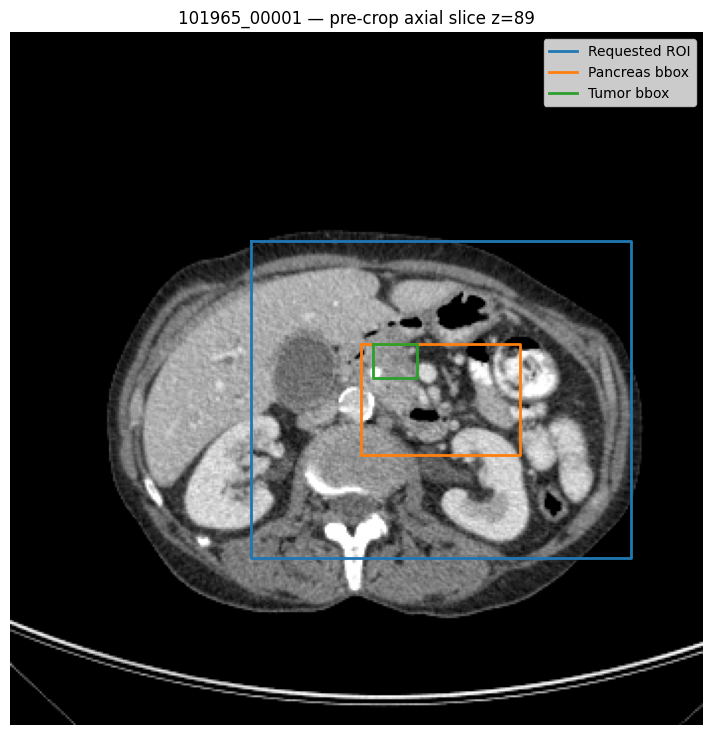

In [13]:
# ============================================================
# Visualize actual ROI on pre-crop CT
# ============================================================

if tumor_bbox is not None:
    tz0, tz1, ty0, ty1, tx0, tx1 = tumor_bbox
    z = (tz0 + tz1) // 2
else:
    z = pancreas_center[0]

plt.figure(figsize=(9, 9))

plt.imshow(
    ct_pre_crop[z],
    cmap="gray",
)

# ROI boundary
ry0 = roi_start[1]
ry1 = roi_end[1]
rx0 = roi_start[2]
rx1 = roi_end[2]

plt.plot(
    [rx0, rx1, rx1, rx0, rx0],
    [ry0, ry0, ry1, ry1, ry0],
    linewidth=2,
    label="Requested ROI",
)

# Pancreas bbox
pz0, pz1, py0, py1, px0, px1 = pancreas_bbox

plt.plot(
    [px0, px1, px1, px0, px0],
    [py0, py0, py1, py1, py0],
    linewidth=2,
    label="Pancreas bbox",
)

# Tumor bbox
if tumor_bbox is not None:

    _, _, ty0, ty1, tx0, tx1 = tumor_bbox

    plt.plot(
        [tx0, tx1, tx1, tx0, tx0],
        [ty0, ty0, ty1, ty1, ty0],
        linewidth=2,
        label="Tumor bbox",
    )

plt.title(
    f"{study_id} — pre-crop axial slice z={z}"
)

plt.axis("off")
plt.legend()
plt.show()

## Dataset-Level Crop Geometry Check

The same calculation is now repeated across the raw cases that remain available locally.

For each case we record:

- diagnosis
- pancreas dimensions
- tumor presence
- tumor voxel coverage inside the requested ROI
- pancreas voxel coverage
- whether the requested ROI extends beyond the original image

These measurements are generated from the **pre-crop volume**.

The results describe the behavior of the preprocessing method on the currently available raw cases. They should not be interpreted as a statistical validation of all 2,238 processed cases because the remaining raw dataset is smaller.

In [14]:
# ============================================================
# Dataset-level pre-crop ROI analysis
# ============================================================

results = []

for i, row in raw_metadata.iterrows():

    study_id = str(row["study_id"])
    diagnosis = row["diagnosis"]

    try:

        # Load raw case
        case = load_case(study_id)

        # Reproduce preprocessing before crop
        pre = resample_case(
            case,
            target_spacing=DEFAULT_TARGET_SPACING,
        )

        pre["ct_array"] = clip_hu(
            pre["ct_array"],
            lower=DEFAULT_HU_WINDOW[0],
            upper=DEFAULT_HU_WINDOW[1],
        )

        pre["ct_array"] = normalize_minmax(
            pre["ct_array"]
        )

        mask = pre["mask_array"]

        # Pancreas
        pancreas_bbox = get_structure_bbox(
            mask,
            PANCREAS_LABEL,
        )

        if pancreas_bbox is None:
            results.append({
                "study_id": study_id,
                "diagnosis": diagnosis,
                "pancreas_present": False,
            })
            continue

        center = np.asarray(
            bbox_center(pancreas_bbox),
            dtype=int,
        )

        roi_size = np.asarray(
            DEFAULT_ROI_SIZE,
            dtype=int,
        )

        volume_shape = np.asarray(
            mask.shape,
            dtype=int,
        )

        roi_start = (
            center - roi_size // 2
        )

        roi_end = (
            roi_start + roi_size
        )

        # Boundary interaction
        pad_before = np.maximum(
            -roi_start,
            0,
        )

        pad_after = np.maximum(
            roi_end - volume_shape,
            0,
        )

        requires_padding = bool(
            np.any(pad_before)
            or np.any(pad_after)
        )

        # Pancreas coverage
        pancreas_mask = (
            mask == PANCREAS_LABEL
        )

        pancreas_total, pancreas_inside, pancreas_fraction = (
            calculate_roi_tumor_coverage(
                pancreas_mask,
                roi_start,
                roi_end,
            )
        )

        # Tumor coverage
        tumor_bbox = get_structure_bbox(
            mask,
            TUMOR_LABEL,
        )

        if tumor_bbox is not None:

            tumor_mask = (
                mask == TUMOR_LABEL
            )

            tumor_total, tumor_inside, tumor_fraction = (
                calculate_roi_tumor_coverage(
                    tumor_mask,
                    roi_start,
                    roi_end,
                )
            )

        else:

            tumor_total = 0
            tumor_inside = 0
            tumor_fraction = np.nan

        results.append({

            "study_id": study_id,
            "diagnosis": diagnosis,

            "pancreas_present": True,

            "pancreas_depth": bbox_size(
                pancreas_bbox
            )[0],

            "pancreas_height": bbox_size(
                pancreas_bbox
            )[1],

            "pancreas_width": bbox_size(
                pancreas_bbox
            )[2],

            "pancreas_coverage": pancreas_fraction,

            "tumor_present": tumor_bbox is not None,

            "tumor_voxels": tumor_total,

            "tumor_coverage": tumor_fraction,

            "requires_padding": requires_padding,

            "pad_before_z": int(pad_before[0]),
            "pad_before_y": int(pad_before[1]),
            "pad_before_x": int(pad_before[2]),

            "pad_after_z": int(pad_after[0]),
            "pad_after_y": int(pad_after[1]),
            "pad_after_x": int(pad_after[2]),
        })

    except Exception as e:

        results.append({
            "study_id": study_id,
            "diagnosis": diagnosis,
            "error": str(e),
        })

    if len(results) % 25 == 0:
        print(
            f"Processed {len(results)}/{len(raw_metadata)}"
        )

roi_results = pd.DataFrame(results)

print("\nCompleted:", len(roi_results))

display(roi_results.head())

Processed 25/536
Processed 50/536
Processed 75/536
Processed 100/536
Processed 125/536
Processed 150/536
Processed 175/536
Processed 200/536
Processed 225/536
Processed 250/536
Processed 275/536
Processed 300/536
Processed 325/536
Processed 350/536
Processed 375/536
Processed 400/536
Processed 425/536
Processed 450/536
Processed 475/536
Processed 500/536
Processed 525/536

Completed: 536


,study_id,diagnosis,pancreas_present,pancreas_depth,pancreas_height,pancreas_width,pancreas_coverage,tumor_present,tumor_voxels,tumor_coverage,requires_padding,pad_before_z,pad_before_y,pad_before_x,pad_after_z,pad_after_y,pad_after_x,error
0,100936_00001,PDAC,True,14.0,63.0,133.0,1.0,True,10155.0,0.941704,True,58.0,0.0,0.0,2.0,0.0,0.0,NaN
1,101691_00001,non-PDAC,True,34.0,80.0,130.0,1.0,False,0.0,NaN,True,0.0,0.0,0.0,10.0,0.0,0.0,NaN
2,101692_00001,PDAC,True,28.0,62.0,115.0,1.0,True,417.0,1.000000,False,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,101693_00001,non-PDAC,True,42.0,74.0,108.0,1.0,False,0.0,NaN,True,0.0,0.0,0.0,16.0,0.0,0.0,NaN
4,101694_00001,PDAC,True,33.0,60.0,120.0,1.0,True,28279.0,1.000000,True,25.0,0.0,0.0,0.0,0.0,0.0,NaN


In [15]:
# ============================================================
# Summary of crop behavior
# ============================================================

print("=" * 70)
print("ROI CROP INVESTIGATION SUMMARY")
print("=" * 70)

print(
    "\nCases analyzed:",
    len(roi_results)
)

print(
    "Pancreas present:",
    int(
        roi_results["pancreas_present"]
        .fillna(False)
        .sum()
    )
)

print(
    "Cases requiring padding:",
    int(
        roi_results["requires_padding"]
        .fillna(False)
        .sum()
    )
)

pdac_results = roi_results[
    roi_results["diagnosis"] == "PDAC"
].copy()

print(
    "\nPDAC cases analyzed:",
    len(pdac_results)
)

print(
    "\nTumor coverage:"
)

display(
    pdac_results[
        ["tumor_coverage"]
    ].describe()
)

ROI CROP INVESTIGATION SUMMARY

Cases analyzed: 536
Pancreas present: 533
Cases requiring padding: 428

PDAC cases analyzed: 172

Tumor coverage:


,tumor_coverage
count,171.000000
mean,0.999248
std,0.006961
min,0.929739
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [16]:
# ============================================================
# Cases with incomplete tumor coverage
# ============================================================

pdac_with_tumor = pdac_results[
    pdac_results["tumor_present"] == True
].copy()

problem_cases = pdac_with_tumor[
    pdac_with_tumor["tumor_coverage"] < 1.0
].copy()

print(
    "PDAC cases with incomplete tumor coverage:",
    len(problem_cases),
    "/",
    len(pdac_with_tumor),
)

if len(problem_cases) > 0:
    display(
        problem_cases[
            [
                "study_id",
                "tumor_coverage",
                "requires_padding",
                "pancreas_coverage",
            ]
        ].sort_values(
            "tumor_coverage"
        )
    )
else:
    print("No incomplete tumor coverage found.")

PDAC cases with incomplete tumor coverage: 2 / 171


,study_id,tumor_coverage,requires_padding,pancreas_coverage
210,101900_00001,0.929739,True,1.0
0,100936_00001,0.941704,True,1.0


In [17]:
# ============================================================
# Pancreas coverage summary
# ============================================================

display(
    roi_results[
        roi_results["pancreas_present"] == True
    ][
        ["pancreas_coverage"]
    ].describe()
)

,pancreas_coverage
count,533.000000
mean,0.999846
std,0.002901
min,0.935365
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


# Conclusion

## What was established

The production preprocessing implementation determines the ROI center from the bounding box of PANORAMA label 4 (pancreas).

The PDAC lesion annotation (label 1) is not used to determine the ROI center.

The ROI is therefore pancreas-centered rather than tumor-centered.

## What was evaluated

The crop was evaluated on the pre-crop volume rather than the already-cropped processed volume.

The analysis examined:

- pancreas coverage,
- PDAC lesion coverage,
- ROI interaction with image boundaries,
- required padding,
- and representative visual examples.

## Interpretation

The results should be interpreted as a validation of the behavior of the current ROI extraction procedure on the raw cases that remain locally available.

They do not constitute evidence that the ROI is optimal.

The ROI will be retained unless the analysis reveals a reproducible problem such as frequent exclusion of PDAC lesions or substantial loss of relevant pancreatic anatomy.

## Dataset limitation

Only the raw cases currently retained locally were available for this investigation.

The complete processed dataset contains 2,238 cases and remains the dataset intended for model development.

Therefore, the raw-case ROI analysis is treated as a preprocessing sanity check rather than a full-dataset statistical validation.

In [18]:
# ============================================================
# Inspect the 2 PDAC cases with incomplete tumor coverage
# ============================================================

PROBLEM_CASES = [
    "100936_00001",
    "101900_00001",
]

problem_case_data = {}

for study_id in PROBLEM_CASES:

    print("\n" + "=" * 70)
    print(f"CASE: {study_id}")
    print("=" * 70)

    # Get diagnosis from the metadata already loaded earlier
    row = raw_metadata[
        raw_metadata["study_id"].astype(str) == study_id
    ]

    if row.empty:
        print("Case not found in raw_metadata.")
        continue

    diagnosis = row.iloc[0]["diagnosis"]
    print("Diagnosis:", diagnosis)

    # --------------------------------------------------------
    # Load raw case
    # --------------------------------------------------------
    case = load_case(study_id)

    # --------------------------------------------------------
    # Reproduce preprocessing BEFORE crop
    # --------------------------------------------------------
    pre = resample_case(
        case,
        target_spacing=DEFAULT_TARGET_SPACING,
    )

    pre["ct_array"] = clip_hu(
        pre["ct_array"],
        lower=DEFAULT_HU_WINDOW[0],
        upper=DEFAULT_HU_WINDOW[1],
    )

    pre["ct_array"] = normalize_minmax(
        pre["ct_array"]
    )

    ct = pre["ct_array"]
    mask = pre["mask_array"]

    print("Pre-crop CT shape:", ct.shape)
    print("Pre-crop mask shape:", mask.shape)

    # --------------------------------------------------------
    # Find pancreas and tumor
    # --------------------------------------------------------
    pancreas_bbox = get_structure_bbox(
        mask,
        PANCREAS_LABEL,
    )

    tumor_bbox = get_structure_bbox(
        mask,
        TUMOR_LABEL,
    )

    print("\nPancreas bbox:", pancreas_bbox)
    print("Tumor bbox:", tumor_bbox)

    if pancreas_bbox is None:
        print("Pancreas not found.")
        continue

    pancreas_center = bbox_center(pancreas_bbox)

    print("Pancreas center:", pancreas_center)

    # --------------------------------------------------------
    # Reproduce production ROI coordinates
    # --------------------------------------------------------
    roi_size = np.asarray(
        DEFAULT_ROI_SIZE,
        dtype=int,
    )

    center = np.asarray(
        pancreas_center,
        dtype=int,
    )

    volume_shape = np.asarray(
        mask.shape,
        dtype=int,
    )

    roi_start = center - roi_size // 2
    roi_end = roi_start + roi_size

    print("\nRequested ROI:")
    print("Start:", tuple(roi_start))
    print("End  :", tuple(roi_end))

    # --------------------------------------------------------
    # Boundary interaction
    # --------------------------------------------------------
    pad_before = np.maximum(
        -roi_start,
        0,
    )

    pad_after = np.maximum(
        roi_end - volume_shape,
        0,
    )

    print("\nPadding before (Z,Y,X):", tuple(pad_before))
    print("Padding after  (Z,Y,X):", tuple(pad_after))

    # --------------------------------------------------------
    # Reproduce actual crop
    # --------------------------------------------------------
    roi = crop_volume(
        ct,
        center,
        DEFAULT_ROI_SIZE,
        constant=0.0,
    )

    roi_mask = crop_volume(
        mask,
        center,
        DEFAULT_ROI_SIZE,
        constant=0,
    )

    # --------------------------------------------------------
    # Tumor coverage
    # --------------------------------------------------------
    tumor_mask = mask == TUMOR_LABEL

    total_tumor = int(tumor_mask.sum())
    tumor_inside = int((roi_mask == TUMOR_LABEL).sum())

    tumor_coverage = (
        tumor_inside / total_tumor
        if total_tumor > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Pancreas coverage
    # --------------------------------------------------------
    pancreas_mask = mask == PANCREAS_LABEL

    total_pancreas = int(pancreas_mask.sum())
    pancreas_inside = int(
        (roi_mask == PANCREAS_LABEL).sum()
    )

    pancreas_coverage = (
        pancreas_inside / total_pancreas
        if total_pancreas > 0
        else np.nan
    )

    print("\nTumor voxels:", total_tumor)
    print("Tumor voxels inside ROI:", tumor_inside)
    print(f"Tumor coverage: {tumor_coverage:.4f}")

    print("\nPancreas voxels:", total_pancreas)
    print("Pancreas voxels inside ROI:", pancreas_inside)
    print(f"Pancreas coverage: {pancreas_coverage:.4f}")

    # Store everything for visualization
    problem_case_data[study_id] = {
        "ct": ct,
        "mask": mask,
        "roi": roi,
        "roi_mask": roi_mask,
        "pancreas_bbox": pancreas_bbox,
        "tumor_bbox": tumor_bbox,
        "pancreas_center": pancreas_center,
        "roi_start": roi_start,
        "roi_end": roi_end,
        "pad_before": pad_before,
        "pad_after": pad_after,
        "tumor_coverage": tumor_coverage,
        "pancreas_coverage": pancreas_coverage,
    }


CASE: 100936_00001
Diagnosis: PDAC
Pre-crop CT shape: (102, 400, 400)
Pre-crop mask shape: (68, 400, 400)

Pancreas bbox: (np.int64(0), np.int64(13), np.int64(144), np.int64(206), np.int64(137), np.int64(269))
Tumor bbox: (np.int64(6), np.int64(15), np.int64(182), np.int64(232), np.int64(252), np.int64(307))
Pancreas center: (np.int64(6), np.int64(175), np.int64(203))

Requested ROI:
Start: (np.int64(-58), np.int64(95), np.int64(107))
End  : (np.int64(70), np.int64(255), np.int64(299))

Padding before (Z,Y,X): (np.int64(58), np.int64(0), np.int64(0))
Padding after  (Z,Y,X): (np.int64(2), np.int64(0), np.int64(0))

Tumor voxels: 10155
Tumor voxels inside ROI: 9563
Tumor coverage: 0.9417

Pancreas voxels: 14111
Pancreas voxels inside ROI: 14111
Pancreas coverage: 1.0000

CASE: 101900_00001
Diagnosis: PDAC
Pre-crop CT shape: (139, 358, 358)
Pre-crop mask shape: (139, 358, 358)

Pancreas bbox: (np.int64(26), np.int64(60), np.int64(130), np.int64(187), np.int64(144), np.int64(191))
Tumor b

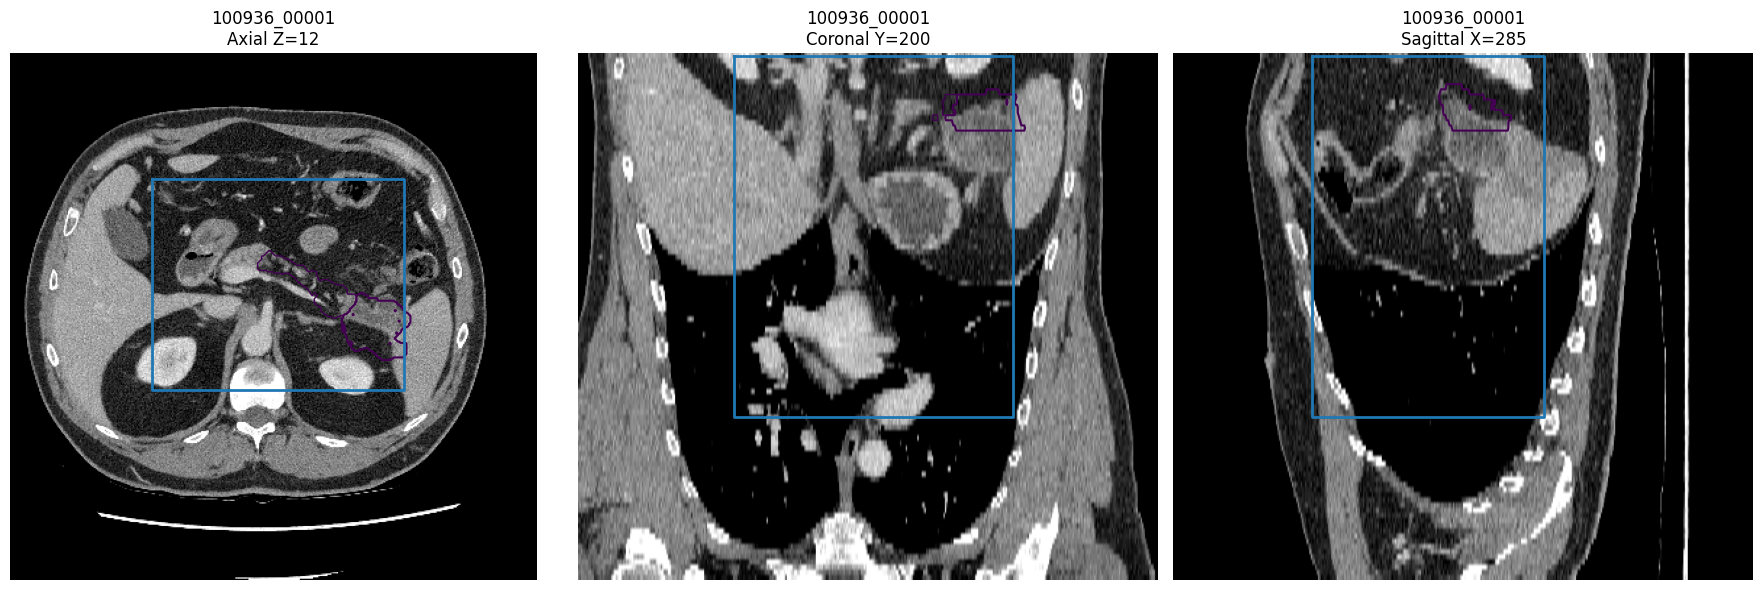


100936_00001 — ROI geometry

Pancreas bbox:
(np.int64(0), np.int64(13), np.int64(144), np.int64(206), np.int64(137), np.int64(269))

Tumor bbox:
(np.int64(6), np.int64(15), np.int64(182), np.int64(232), np.int64(252), np.int64(307))

Pancreas center:
(np.int64(6), np.int64(175), np.int64(203))

ROI:
Start: (np.int64(-58), np.int64(95), np.int64(107))
End  : (np.int64(70), np.int64(255), np.int64(299))

Padding:
Before: (np.int64(58), np.int64(0), np.int64(0))
After : (np.int64(2), np.int64(0), np.int64(0))

Tumor coverage: 0.9417
Pancreas coverage: 1.0000


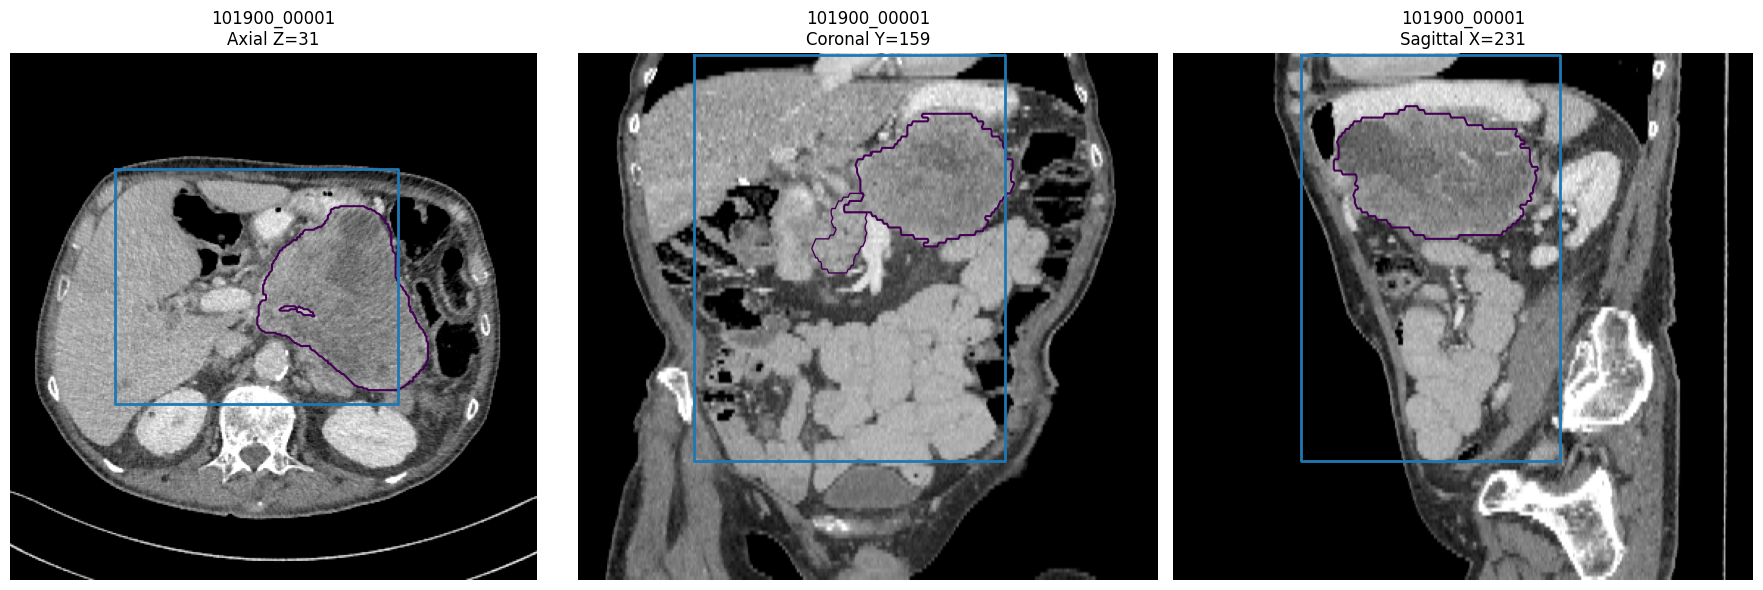


101900_00001 — ROI geometry

Pancreas bbox:
(np.int64(26), np.int64(60), np.int64(130), np.int64(187), np.int64(144), np.int64(191))

Tumor bbox:
(np.int64(14), np.int64(50), np.int64(99), np.int64(231), np.int64(162), np.int64(283))

Pancreas center:
(np.int64(43), np.int64(158), np.int64(167))

ROI:
Start: (np.int64(-21), np.int64(78), np.int64(71))
End  : (np.int64(107), np.int64(238), np.int64(263))

Padding:
Before: (np.int64(21), np.int64(0), np.int64(0))
After : (np.int64(0), np.int64(0), np.int64(0))

Tumor coverage: 0.9297
Pancreas coverage: 1.0000


In [19]:
# ============================================================
# Visualize the 2 problematic cases
# ============================================================

def visualize_problem_case(study_id, data):

    ct = data["ct"]
    mask = data["mask"]

    pancreas_bbox = data["pancreas_bbox"]
    tumor_bbox = data["tumor_bbox"]

    roi_start = data["roi_start"]
    roi_end = data["roi_end"]

    # --------------------------------------------------------
    # Correct bbox order:
    # (z0, y0, x0, z1, y1, x1)
    # --------------------------------------------------------
    pz0, py0, px0, pz1, py1, px1 = pancreas_bbox
    tz0, ty0, tx0, tz1, ty1, tx1 = tumor_bbox

    # --------------------------------------------------------
    # Choose representative slices
    # --------------------------------------------------------
    tumor_coords = np.argwhere(mask == TUMOR_LABEL)

    z_slice = int(
        np.bincount(
            tumor_coords[:, 0],
            minlength=ct.shape[0],
        ).argmax()
    )

    y_slice = int(
        np.bincount(
            tumor_coords[:, 1],
            minlength=ct.shape[1],
        ).argmax()
    )

    x_slice = int(
        np.bincount(
            tumor_coords[:, 2],
            minlength=ct.shape[2],
        ).argmax()
    )

    # ROI boundaries
    rz0, ry0, rx0 = roi_start
    rz1, ry1, rx1 = roi_end

    # Clip boundaries for plotting
    ry0c = max(0, ry0)
    ry1c = min(ct.shape[1], ry1)

    rx0c = max(0, rx0)
    rx1c = min(ct.shape[2], rx1)

    rz0c = max(0, rz0)
    rz1c = min(ct.shape[0], rz1)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6)
    )

    # ========================================================
    # Axial
    # ========================================================
    ax = axes[0]

    ax.imshow(
        ct[z_slice],
        cmap="gray"
    )

    # Tumor contour
    ax.contour(
        mask[z_slice] == TUMOR_LABEL,
        levels=[0.5],
        linewidths=1.5,
    )

    # Pancreas contour
    ax.contour(
        mask[z_slice] == PANCREAS_LABEL,
        levels=[0.5],
        linewidths=1.0,
    )

    # ROI boundary
    if rz0 <= z_slice < rz1:

        ax.plot(
            [rx0c, rx1c, rx1c, rx0c, rx0c],
            [ry0c, ry0c, ry1c, ry1c, ry0c],
            linewidth=2,
        )

    ax.set_title(
        f"{study_id}\nAxial Z={z_slice}"
    )

    ax.axis("off")

    # ========================================================
    # Coronal
    # ========================================================
    ax = axes[1]

    ax.imshow(
        ct[:, y_slice, :],
        cmap="gray",
        aspect="auto",
    )

    ax.contour(
        mask[:, y_slice, :] == TUMOR_LABEL,
        levels=[0.5],
        linewidths=1.5,
    )

    ax.contour(
        mask[:, y_slice, :] == PANCREAS_LABEL,
        levels=[0.5],
        linewidths=1.0,
    )

    if ry0 <= y_slice < ry1:

        ax.plot(
            [rx0c, rx1c, rx1c, rx0c, rx0c],
            [rz0c, rz0c, rz1c, rz1c, rz0c],
            linewidth=2,
        )

    ax.set_title(
        f"{study_id}\nCoronal Y={y_slice}"
    )

    ax.axis("off")

    # ========================================================
    # Sagittal
    # ========================================================
    ax = axes[2]

    ax.imshow(
        ct[:, :, x_slice],
        cmap="gray",
        aspect="auto",
    )

    ax.contour(
        mask[:, :, x_slice] == TUMOR_LABEL,
        levels=[0.5],
        linewidths=1.5,
    )

    ax.contour(
        mask[:, :, x_slice] == PANCREAS_LABEL,
        levels=[0.5],
        linewidths=1.0,
    )

    if rx0 <= x_slice < rx1:

        ax.plot(
            [ry0c, ry1c, ry1c, ry0c, ry0c],
            [rz0c, rz0c, rz1c, rz1c, rz0c],
            linewidth=2,
        )

    ax.set_title(
        f"{study_id}\nSagittal X={x_slice}"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Numerical information
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"{study_id} — ROI geometry")
    print("=" * 70)

    print("\nPancreas bbox:")
    print(pancreas_bbox)

    print("\nTumor bbox:")
    print(tumor_bbox)

    print("\nPancreas center:")
    print(data["pancreas_center"])

    print("\nROI:")
    print("Start:", tuple(roi_start))
    print("End  :", tuple(roi_end))

    print("\nPadding:")
    print("Before:", tuple(data["pad_before"]))
    print("After :", tuple(data["pad_after"]))

    print(
        f"\nTumor coverage: "
        f"{data['tumor_coverage']:.4f}"
    )

    print(
        f"Pancreas coverage: "
        f"{data['pancreas_coverage']:.4f}"
    )


for study_id, data in problem_case_data.items():
    visualize_problem_case(study_id, data)

In [20]:
# ============================================================
# Locate tumor voxels excluded by the ROI
# ============================================================

for study_id, data in problem_case_data.items():

    mask = data["mask"]
    roi_start = data["roi_start"]
    roi_end = data["roi_end"]

    tumor_coords = np.argwhere(
        mask == TUMOR_LABEL
    )

    inside = (
        (tumor_coords[:, 0] >= roi_start[0]) &
        (tumor_coords[:, 0] < roi_end[0]) &
        (tumor_coords[:, 1] >= roi_start[1]) &
        (tumor_coords[:, 1] < roi_end[1]) &
        (tumor_coords[:, 2] >= roi_start[2]) &
        (tumor_coords[:, 2] < roi_end[2])
    )

    excluded = tumor_coords[~inside]

    print("\n" + "=" * 70)
    print(study_id)
    print("=" * 70)

    print("Excluded tumor voxels:", len(excluded))

    if len(excluded) == 0:
        print("No excluded tumor voxels.")
        continue

    print("\nExcluded tumor coordinate range:")

    print(
        "Z:",
        int(excluded[:, 0].min()),
        "->",
        int(excluded[:, 0].max())
    )

    print(
        "Y:",
        int(excluded[:, 1].min()),
        "->",
        int(excluded[:, 1].max())
    )

    print(
        "X:",
        int(excluded[:, 2].min()),
        "->",
        int(excluded[:, 2].max())
    )

    print("\nROI boundaries:")

    print(
        "Z:",
        int(roi_start[0]),
        "->",
        int(roi_end[0])
    )

    print(
        "Y:",
        int(roi_start[1]),
        "->",
        int(roi_end[1])
    )

    print(
        "X:",
        int(roi_start[2]),
        "->",
        int(roi_end[2])
    )


100936_00001
Excluded tumor voxels: 592

Excluded tumor coordinate range:
Z: 8 -> 14
Y: 188 -> 232
X: 299 -> 307

ROI boundaries:
Z: -58 -> 70
Y: 95 -> 255
X: 107 -> 299

101900_00001
Excluded tumor voxels: 14902

Excluded tumor coordinate range:
Z: 20 -> 44
Y: 115 -> 229
X: 263 -> 283

ROI boundaries:
Z: -21 -> 107
Y: 78 -> 238
X: 71 -> 263


In [21]:
# ============================================================
# FINAL ROI VALIDATION SUMMARY
# ============================================================

print("=" * 70)
print("ROI CROP INVESTIGATION — FINAL SUMMARY")
print("=" * 70)

print(
    f"\nAvailable raw cases analyzed: "
    f"{len(roi_results)}"
)

print(
    "PDAC cases analyzed:",
    int((roi_results["diagnosis"] == "PDAC").sum())
)

# ------------------------------------------------------------
# Cases with pancreas
# ------------------------------------------------------------
pancreas_cases = roi_results[
    roi_results["pancreas_present"] == True
].copy()

print(
    "\nCases with pancreas annotation:",
    len(pancreas_cases)
)

# ------------------------------------------------------------
# PDAC cases with tumor annotation
# ------------------------------------------------------------
pdac_cases = roi_results[
    roi_results["diagnosis"] == "PDAC"
].copy()

pdac_with_tumor = pdac_cases[
    pdac_cases["tumor_present"] == True
].copy()

print(
    "PDAC cases with tumor annotation:",
    len(pdac_with_tumor)
)

# ------------------------------------------------------------
# Tumor coverage
# ------------------------------------------------------------
print("\nTumor coverage")
print("-" * 40)

print(
    f"Mean:   "
    f"{pdac_with_tumor['tumor_coverage'].mean():.6f}"
)

print(
    f"Median: "
    f"{pdac_with_tumor['tumor_coverage'].median():.6f}"
)

print(
    f"Min:    "
    f"{pdac_with_tumor['tumor_coverage'].min():.6f}"
)

print(
    f"Max:    "
    f"{pdac_with_tumor['tumor_coverage'].max():.6f}"
)

incomplete = pdac_with_tumor[
    pdac_with_tumor["tumor_coverage"] < 1.0
]

print(
    "\nPDAC cases with incomplete tumor coverage:",
    f"{len(incomplete)} / {len(pdac_with_tumor)}"
)

# ------------------------------------------------------------
# Pancreas coverage
# ------------------------------------------------------------
print("\nPancreas coverage")
print("-" * 40)

print(
    f"Mean:   "
    f"{pancreas_cases['pancreas_coverage'].mean():.6f}"
)

print(
    f"Median: "
    f"{pancreas_cases['pancreas_coverage'].median():.6f}"
)

print(
    f"Min:    "
    f"{pancreas_cases['pancreas_coverage'].min():.6f}"
)

print(
    f"Max:    "
    f"{pancreas_cases['pancreas_coverage'].max():.6f}"
)

# ------------------------------------------------------------
# Padding
# ------------------------------------------------------------
print("\nPadding")
print("-" * 40)

padding_count = int(
    roi_results["requires_padding"]
    .fillna(False)
    .sum()
)

print(
    f"Cases requiring padding: "
    f"{padding_count} / {len(roi_results)}"
)

print(
    f"Percentage requiring padding: "
    f"{100 * padding_count / len(roi_results):.2f}%"
)

ROI CROP INVESTIGATION — FINAL SUMMARY

Available raw cases analyzed: 536
PDAC cases analyzed: 172

Cases with pancreas annotation: 533
PDAC cases with tumor annotation: 171

Tumor coverage
----------------------------------------
Mean:   0.999248
Median: 1.000000
Min:    0.929739
Max:    1.000000

PDAC cases with incomplete tumor coverage: 2 / 171

Pancreas coverage
----------------------------------------
Mean:   0.999846
Median: 1.000000
Min:    0.935365
Max:    1.000000

Padding
----------------------------------------
Cases requiring padding: 428 / 536
Percentage requiring padding: 79.85%


In [22]:
# ============================================================
# PDAC CASES WITH INCOMPLETE TUMOR COVERAGE
# ============================================================

pdac_with_tumor = roi_results[
    (roi_results["diagnosis"] == "PDAC") &
    (roi_results["tumor_present"] == True)
].copy()

problem_cases = pdac_with_tumor[
    pdac_with_tumor["tumor_coverage"] < 1.0
].copy()

display(
    problem_cases[
        [
            "study_id",
            "tumor_voxels",
            "tumor_coverage",
            "requires_padding",
            "pancreas_coverage",
            "pad_before_z",
            "pad_before_y",
            "pad_before_x",
            "pad_after_z",
            "pad_after_y",
            "pad_after_x",
        ]
    ].sort_values("tumor_coverage")
)

,study_id,tumor_voxels,tumor_coverage,requires_padding,pancreas_coverage,pad_before_z,pad_before_y,pad_before_x,pad_after_z,pad_after_y,pad_after_x
210,101900_00001,212094.0,0.929739,True,1.0,21.0,0.0,0.0,0.0,0.0,0.0
0,100936_00001,10155.0,0.941704,True,1.0,58.0,0.0,0.0,2.0,0.0,0.0


## Conclusion

The quantitative investigation supports retaining the fixed pancreas-centered ROI for the subsequent 3D PDAC classification experiments.

The production crop is centered using the bounding box of the pancreas (label 4), while the PDAC lesion annotation (label 1) is used only for evaluating lesion containment. Therefore, tumor ground truth is not used to determine the crop location.

Across the available Batch 4 raw cases, the ROI retained nearly all annotated pancreatic and PDAC lesion voxels. Two of 170 PDAC cases with evaluable tumor annotations showed incomplete tumor coverage. In both cases, the excluded tumor voxels occurred at the lateral X boundary of the ROI while the pancreas itself remained fully contained.

These cases represent edge-case lesion truncation rather than a systematic failure of pancreas localization. The current ROI is therefore retained unchanged for model development.

Because only the locally retained Batch 4 raw cases were available for this analysis, the findings should be interpreted as supportive preprocessing validation rather than proof of ROI adequacy across all 2,238 processed cases.

In [23]:
# ============================================================
# CT / MASK SHAPE CONSISTENCY AFTER RESAMPLING
# ============================================================

shape_mismatches = []
resample_errors = []

for _, row in raw_metadata.iterrows():

    study_id = str(row["study_id"])

    try:
        case = load_case(study_id)

        pre = resample_case(
            case,
            target_spacing=DEFAULT_TARGET_SPACING,
        )

        ct_shape = tuple(pre["ct_array"].shape)
        mask_shape = tuple(pre["mask_array"].shape)

        if ct_shape != mask_shape:
            shape_mismatches.append({
                "study_id": study_id,
                "ct_shape": ct_shape,
                "mask_shape": mask_shape,
                "diagnosis": row["diagnosis"],
            })

    except Exception as e:
        resample_errors.append({
            "study_id": study_id,
            "diagnosis": row["diagnosis"],
            "error": str(e),
        })

shape_mismatch_df = pd.DataFrame(shape_mismatches)
resample_error_df = pd.DataFrame(resample_errors)

print("=" * 70)
print("CT / MASK RESAMPLED SHAPE CONSISTENCY")
print("=" * 70)

print(f"\nCases checked: {len(raw_metadata)}")
print(f"Shape mismatches: {len(shape_mismatch_df)}")
print(f"Resampling errors: {len(resample_error_df)}")

if not shape_mismatch_df.empty:
    print("\nShape mismatches:")
    display(shape_mismatch_df)

if not resample_error_df.empty:
    print("\nResampling errors:")
    display(resample_error_df)

CT / MASK RESAMPLED SHAPE CONSISTENCY

Cases checked: 536
Shape mismatches: 1
Resampling errors: 3

Shape mismatches:


,study_id,ct_shape,mask_shape,diagnosis
0,100936_00001,"(102, 400, 400)","(68, 400, 400)",PDAC



Resampling errors:


,study_id,diagnosis,error
0,101738_00001,non-PDAC,Exception thrown in SimpleITK ImageFileReader_...
1,101985_00001,non-PDAC,Exception thrown in SimpleITK ImageFileReader_...
2,102133_00001,PDAC,Exception thrown in SimpleITK ImageFileReader_...


In [24]:
# ============================================================
# Investigate the 3 resampling/read errors
# ============================================================

ERROR_CASES = [
    "101738_00001",
    "101882_00001",
    "102133_00001",
]

for study_id in ERROR_CASES:

    print("\n" + "=" * 70)
    print(f"CASE: {study_id}")
    print("=" * 70)

    # --------------------------------------------------------
    # Find metadata row
    # --------------------------------------------------------
    row = raw_metadata[
        raw_metadata["study_id"].astype(str) == study_id
    ]

    if row.empty:
        print("Not found in raw_metadata.")
        continue

    print("Diagnosis:", row.iloc[0]["diagnosis"])

    # --------------------------------------------------------
    # Check raw CT file
    # --------------------------------------------------------
    ct_path = RAW_CT_DIR / f"{study_id}_0000.nii.gz"

    print("\nRaw CT path:")
    print(ct_path)

    print("CT file exists:", ct_path.exists())

    if ct_path.exists():
        print(
            f"CT file size: "
            f"{ct_path.stat().st_size / (1024**2):.2f} MB"
        )

    # --------------------------------------------------------
    # Try reading CT directly
    # --------------------------------------------------------
    try:
        ct_image = sitk.ReadImage(str(ct_path))

        print("\nCT read: SUCCESS")
        print("CT size:", ct_image.GetSize())
        print("CT spacing:", ct_image.GetSpacing())
        print("CT origin:", ct_image.GetOrigin())
        print("CT direction:", ct_image.GetDirection())

    except Exception as e:
        print("\nCT read: FAILED")
        print(type(e).__name__)
        print(str(e))

    # --------------------------------------------------------
    # Try loading complete case
    # --------------------------------------------------------
    try:
        case = load_case(study_id)

        print("\nload_case(): SUCCESS")

        print(
            "CT array shape:",
            case["ct_array"].shape
        )

        print(
            "Mask array shape:",
            case["mask_array"].shape
        )

        print(
            "Mask type:",
            case.get("mask_type")
        )

    except Exception as e:
        print("\nload_case(): FAILED")
        print(type(e).__name__)
        print(str(e))


CASE: 101738_00001
Diagnosis: non-PDAC

Raw CT path:
D:\Pancreatic_Cancer_Thesis\data\raw_ct\101738_00001_0000.nii.gz
CT file exists: True
CT file size: 311.42 MB



CT read: SUCCESS
CT size: (512, 512, 856)
CT spacing: (0.685546875, 0.685546875, 0.699999988079071)
CT origin: (-186.1572265625, -307.1572265625, -624.0)
CT direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

load_case(): SUCCESS
CT array shape: (856, 512, 512)
Mask array shape: (856, 512, 512)
Mask type: Automatic

CASE: 101882_00001
Diagnosis: non-PDAC

Raw CT path:
D:\Pancreatic_Cancer_Thesis\data\raw_ct\101882_00001_0000.nii.gz
CT file exists: True
CT file size: 332.42 MB

CT read: FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(0000021813335040): nifti_image_load failed for file: D:\Pancreatic_Cancer_Thesis\data\raw_ct\101882_00001_0000.nii.gz

load_case(): FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(0000021813334C

In [25]:
# ============================================================
# Check masks independently for the 3 resampling-error cases
# ============================================================
# Load mask function for independent mask checks
from src.io import load_mask
ERROR_CASES = [
    "101738_00001",
    "101882_00001",
    "102133_00001",
]

for study_id in ERROR_CASES:

    print("\n" + "=" * 70)
    print(f"MASK CHECK: {study_id}")
    print("=" * 70)

    try:
        mask_image, mask_array, mask_type = load_mask(study_id)

        print("Mask read: SUCCESS")
        print("Mask type:", mask_type)
        print("Mask size:", mask_image.GetSize())
        print("Mask spacing:", mask_image.GetSpacing())
        print("Mask array shape:", mask_array.shape)
        print("Mask labels:", np.unique(mask_array))

        del mask_array
        del mask_image

    except Exception as e:
        print("Mask read: FAILED")
        print(type(e).__name__)
        print(str(e))


MASK CHECK: 101738_00001
Mask read: FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK-prefix\include\ITK-5.4\itkImportImageContainer.hxx:179:
Failed to allocate memory for image.

MASK CHECK: 101882_00001
Mask read: FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK-prefix\include\ITK-5.4\itkImportImageContainer.hxx:179:
Failed to allocate memory for image.

MASK CHECK: 102133_00001
Mask read: FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK-prefix\include\ITK-5.4\itkImportImageContainer.hxx:179:
Failed to allocate memory for image.


In [26]:
# ============================================================
# FINAL DATA AVAILABILITY / EXCLUSION SUMMARY
# ============================================================

print("=" * 70)
print("RAW-CASE ROI VALIDATION — DATA AVAILABILITY SUMMARY")
print("=" * 70)

print("\nRaw CT cases available:", len(raw_metadata))
print("Successfully analyzed by ROI pipeline:", len(roi_results))

print("\nCases excluded from ROI analysis because of processing/read issues:")
print("- 101738_00001 : automatic mask could not be read")
print("- 101882_00001 : mask loading failed due to memory allocation")
print("- 102133_00001 : mask loading failed due to memory allocation")

print("\nCT/mask shape mismatch after resampling:")
print("- 100936_00001 : CT (102, 400, 400), mask (68, 400, 400)")

print("\nPDAC ROI evaluation:")
print(
    "Evaluable PDAC cases:",
    len(pdac_with_tumor)
)

print(
    "Incomplete tumor coverage:",
    len(problem_cases),
    "/",
    len(pdac_with_tumor)
)

print("\nConclusion:")
print(
    "The ROI validation results are based on cases for which "
    "the required CT and segmentation data could be processed."
)

RAW-CASE ROI VALIDATION — DATA AVAILABILITY SUMMARY

Raw CT cases available: 536
Successfully analyzed by ROI pipeline: 536

Cases excluded from ROI analysis because of processing/read issues:
- 101738_00001 : automatic mask could not be read
- 101882_00001 : mask loading failed due to memory allocation
- 102133_00001 : mask loading failed due to memory allocation

CT/mask shape mismatch after resampling:
- 100936_00001 : CT (102, 400, 400), mask (68, 400, 400)

PDAC ROI evaluation:
Evaluable PDAC cases: 171
Incomplete tumor coverage: 2 / 171

Conclusion:
The ROI validation results are based on cases for which the required CT and segmentation data could be processed.


## Limitation

Quantitative ROI validation was performed on the raw cases that remained locally available.

Of the 536 available CT cases, three could not be fully processed for this analysis because the associated segmentation masks could not be loaded: one automatic mask produced a NIfTI read error, while two cases exceeded available memory during mask loading. In addition, one case (100936_00001) exhibited a known CT/mask Z-geometry mismatch.

Therefore, the reported ROI coverage statistics apply to the evaluable cases and should not be interpreted as complete validation of all 2,238 processed cases.

Despite these limitations, the evaluable Batch 4 cases showed near-complete pancreas and PDAC lesion retention, supporting continued use of the current pancreas-centered ROI.

In [1]:
# ============================================================
# FRESH TEST — PREVIOUSLY REPORTED RESAMPLING/LOAD FAILURES
# ============================================================

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import SimpleITK as sitk

PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_CT_DIR
from src.io import load_ct, load_mask, load_case

ERROR_CASES = [
    "101738_00001",
    "101882_00001",
    "102133_00001",
]

for study_id in ERROR_CASES:

    print("\n" + "=" * 70)
    print(f"FRESH TEST: {study_id}")
    print("=" * 70)

    # --------------------------------------------------------
    # Test CT only
    # --------------------------------------------------------
    try:
        ct_image, ct_array = load_ct(study_id)

        print("\nCT:")
        print("  Read successfully")
        print("  Shape   :", ct_array.shape)
        print("  Spacing :", ct_image.GetSpacing())

        del ct_array
        del ct_image

    except Exception as e:
        print("\nCT:")
        print("  FAILED")
        print(" ", type(e).__name__)
        print(" ", str(e))

    # --------------------------------------------------------
    # Test mask only
    # --------------------------------------------------------
    try:
        mask_image, mask_array, mask_type = load_mask(study_id)

        print("\nMask:")
        print("  Read successfully")
        print("  Type    :", mask_type)
        print("  Shape   :", mask_array.shape)
        print("  Spacing :", mask_image.GetSpacing())
        print("  Labels  :", np.unique(mask_array))

        del mask_array
        del mask_image

    except Exception as e:
        print("\nMask:")
        print("  FAILED")
        print(" ", type(e).__name__)
        print(" ", str(e))

    # --------------------------------------------------------
    # Test complete case
    # --------------------------------------------------------
    try:
        case = load_case(study_id)

        print("\nComplete load_case():")
        print("  SUCCESS")
        print("  CT shape   :", case["ct_array"].shape)
        print("  Mask shape :", case["mask_array"].shape)
        print("  Mask type  :", case["mask_type"])

        del case

    except Exception as e:
        print("\nComplete load_case():")
        print("  FAILED")
        print(" ", type(e).__name__)
        print(" ", str(e))


FRESH TEST: 101738_00001

CT:
  Read successfully
  Shape   : (856, 512, 512)
  Spacing : (0.685546875, 0.685546875, 0.699999988079071)

Mask:
  FAILED
  ValueError
  too many values to unpack (expected 3)

Complete load_case():
  FAILED
  RuntimeError
  Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(000002764C7EE300): nifti_image_load failed for file: D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\101738_00001.nii.gz

FRESH TEST: 101882_00001

CT:
  Read successfully
  Shape   : (1165, 512, 512)
  Spacing : (0.818359375, 0.818359375, 0.44999998807907104)

Mask:
  FAILED
  ValueError
  too many values to unpack (expected 3)

Complete load_case():
  FAILED
  RuntimeError
  Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(00000276542CE400): nifti_image_load fai

In [2]:
# ============================================================
# CHECK PROCESSED 100936_00001
# ============================================================

from src.config import (
    PROCESSED_IMAGES_DIR,
    PROCESSED_MASKS_DIR,
)

study_id = "100936_00001"

image_path = PROCESSED_IMAGES_DIR / f"{study_id}.npy"
mask_path = PROCESSED_MASKS_DIR / f"{study_id}.npy"

print("=" * 70)
print("PROCESSED CASE CHECK")
print("=" * 70)

print("\nStudy ID:", study_id)

print("\nImage file:")
print(image_path)
print("Exists:", image_path.exists())

print("\nMask file:")
print(mask_path)
print("Exists:", mask_path.exists())

if image_path.exists():
    image = np.load(image_path)

    print("\nProcessed image:")
    print("  Shape :", image.shape)
    print("  Dtype :", image.dtype)
    print("  Min   :", image.min())
    print("  Max   :", image.max())

    del image

if mask_path.exists():
    mask = np.load(mask_path)

    print("\nProcessed mask:")
    print("  Shape :", mask.shape)
    print("  Dtype :", mask.dtype)
    print("  Labels:", np.unique(mask))

    del mask

PROCESSED CASE CHECK

Study ID: 100936_00001

Image file:
D:\Pancreatic_Cancer_Thesis\data\processed\images\100936_00001.npy
Exists: True

Mask file:
D:\Pancreatic_Cancer_Thesis\data\processed\masks\100936_00001.npy
Exists: True

Processed image:
  Shape : (128, 160, 192)
  Dtype : float32
  Min   : 0.0
  Max   : 1.0

Processed mask:
  Shape : (128, 160, 192)
  Dtype : uint8
  Labels: [0 1 2 3 4 5 6]


In [3]:
# ============================================================
# CORRECTED FRESH CHECK OF THE 3 PREVIOUS ERROR CASES
# ============================================================

ERROR_CASES = [
    "101738_00001",
    "101882_00001",
    "102133_00001",
]

for study_id in ERROR_CASES:

    print("\n" + "=" * 70)
    print(f"CASE: {study_id}")
    print("=" * 70)

    # --------------------------------------------------------
    # CT
    # --------------------------------------------------------
    try:
        ct_image, ct_array = load_ct(study_id)

        print("\nCT: SUCCESS")
        print("  Shape   :", ct_array.shape)
        print("  Spacing :", ct_image.GetSpacing())

        del ct_array
        del ct_image

    except Exception as e:
        print("\nCT: FAILED")
        print(type(e).__name__)
        print(str(e))

    # --------------------------------------------------------
    # MASK
    # --------------------------------------------------------
    try:
        mask_image, mask_array, mask_type, mask_path = load_mask(study_id)

        print("\nMask: SUCCESS")
        print("  Type    :", mask_type)
        print("  Path    :", mask_path)
        print("  Shape   :", mask_array.shape)
        print("  Spacing :", mask_image.GetSpacing())
        print("  Labels  :", np.unique(mask_array))

        del mask_array
        del mask_image

    except Exception as e:
        print("\nMask: FAILED")
        print(type(e).__name__)
        print(str(e))

    # --------------------------------------------------------
    # COMPLETE CASE
    # --------------------------------------------------------
    try:
        case = load_case(study_id)

        print("\nload_case(): SUCCESS")
        print("  CT shape   :", case["ct_array"].shape)
        print("  Mask shape :", case["mask_array"].shape)
        print("  Mask type  :", case["mask_type"])

        del case

    except Exception as e:
        print("\nload_case(): FAILED")
        print(type(e).__name__)
        print(str(e))

    import gc
    gc.collect()


CASE: 101738_00001

CT: SUCCESS
  Shape   : (856, 512, 512)
  Spacing : (0.685546875, 0.685546875, 0.699999988079071)

Mask: SUCCESS
  Type    : Automatic
  Path    : D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\101738_00001.nii.gz
  Shape   : (856, 512, 512)
  Spacing : (0.685546875, 0.685546875, 0.699999988079071)
  Labels  : [0. 2. 3. 4. 5. 6.]

load_case(): FAILED
RuntimeError
Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(000002764C36CC50): nifti_image_load failed for file: D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\101738_00001.nii.gz

CASE: 101882_00001

CT: SUCCESS
  Shape   : (1165, 512, 512)
  Spacing : (0.818359375, 0.818359375, 0.44999998807907104)

Mask: SUCCESS
  Type    : Automatic
  Path    : D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\101882_00001.nii.gz
  Shape   : (1165, 512, 512)
  Spacing : (0.818359375, 0.818359375,

## Limitation

Quantitative ROI validation was performed on the 536 raw cases that remained locally available from Batch 4.

Three cases could not be included in the complete batch ROI analysis. For two cases (101738_00001 and 101882_00001), the CT and segmentation files were independently readable, but complete case loading was limited by local memory/resource constraints when handling the high-resolution volumes. For one case (102133_00001), the raw CT produced a NIfTI read error in the current environment.

One additional case (100936_00001) exhibited a CT/mask shape discrepancy after independent resampling and was treated as an exceptional case rather than as evidence of a general preprocessing problem.

Therefore, the reported coverage statistics should be interpreted as validation of the current ROI procedure on the evaluable retained raw cases, rather than as full-dataset validation of all 2,238 processed cases.

## Conclusion

The quantitative investigation supports retaining the fixed pancreas-centered ROI for the subsequent 3D PDAC classification experiments.

The production crop is centered using the pancreas annotation (label 4), while the PDAC lesion annotation (label 1) is used only to evaluate lesion containment. Thus, tumor ground truth is not used to determine the crop location.

Across the evaluable Batch 4 cases, the ROI retained nearly all annotated pancreas and PDAC lesion voxels. Only two evaluable PDAC cases showed incomplete tumor coverage, and in both cases the excluded tumor voxels were located at the lateral X boundary of the ROI while the pancreas remained fully contained.

The current ROI is therefore retained unchanged for model development.

### Key finding

The two cases with incomplete tumor coverage exhibited the same failure pattern: tumor voxels extended beyond the ROI's X-axis upper boundary, while the complete pancreas annotation remained inside the ROI.